# 👁️ Eye Recognition using Deep Learning

This notebook presents an advanced deep learning pipeline for Eye Recognition using a fine-tuned ResNet50 backbone combined with a custom CNN classifier head.

## 🔥 Key Features
- Automated dataset parsing
- Advanced preprocessing pipeline
- Two-phase transfer learning
- Enhanced callbacks
- Detailed evaluation & visualization
- Confidence-based predictions

---

📌 Framework: TensorFlow / Keras  
📌 Backbone: ResNet50  
📌 Input Size: 224x224 

In [1]:
 
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
class Config:
    DATA_ROOT = Path(r"C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H")  
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 20
    LEARNING_RATE = 1e-4

config = Config()


In [3]:
def collect_dataset_info(data_root):
    IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')
    records = []

    for person_dir in data_root.iterdir():
        if person_dir.is_dir():
            for img_path in person_dir.glob("*"):
                if img_path.suffix.lower() in IMG_EXTS:
                    records.append({
                        "image_path": str(img_path),
                        "label": person_dir.name
                    })

    return pd.DataFrame(records)

df = collect_dataset_info(config.DATA_ROOT)
print(f"Total samples: {len(df)}")
df.head()


Total samples: 680


,image_path,label
0,C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H\amr...,amr_khaled
1,C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H\amr...,amr_khaled
2,C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H\amr...,amr_khaled
3,C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H\amr...,amr_khaled
4,C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H\amr...,amr_khaled


In [4]:
def preprocess_image(image_path, img_size):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img = img / 255.0
    return img

def prepare_dataset(df, img_size):
    images = []
    labels = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        images.append(preprocess_image(row["image_path"], img_size))
        labels.append(row["label"])

    return np.array(images), np.array(labels)

X, y = prepare_dataset(df, config.IMG_SIZE)


100%|███████████████████████████████████████████████████████████████████████████████| 680/680 [00:02<00:00, 246.73it/s]


In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


Number of classes: 4


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import AdamW


def create_stronger_model(input_shape, num_classes, base_trainable=False):

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = base_trainable

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)

    x1 = layers.BatchNormalization()(x)
    x1 = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(x1)
    x1 = layers.Activation("gelu")(x1)
    x1 = layers.Dropout(0.5)(x1)

    x2 = layers.BatchNormalization()(x1)
    x2 = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x2)
    x2 = layers.Activation("gelu")(x2)
    x2 = layers.Dropout(0.4)(x2)

    x = layers.Concatenate()([x1, x2])

    x = layers.Dense(
        256,
        activation="gelu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    optimizer = AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


input_shape = (*config.IMG_SIZE, 3)
model, base_model = create_stronger_model(input_shape, num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 2048)              │           8,192 │ global_average_pooling2d[… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 1024)              │       2,098,176 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 1024)              │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 1024)              │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 1024)              │           4,096 │ dropout[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 512)               │         524,800 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 512)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 512)               │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1536)              │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 256)               │         393,472 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 256)               │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 4)                 │           1,028 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴───────────────

 Total params: 26,617,476 (101.54 MB)

 Trainable params: 3,023,620 (11.53 MB)

 Non-trainable params: 23,593,856 (90.00 MB)

In [7]:
callbacks = [
    EarlyStopping(monitor='val_accuracy',patience=7,restore_best_weights=True,verbose=1,mode='max'),
    ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=10,min_lr=1e-7,verbose=1),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]


In [8]:
print("Starting Two-Phase Training")
print("=" * 60)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("\n Phase 1: Training classifier)")

base_model.trainable = False

optimizer_phase1 = AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer_phase1,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_phase1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\nPhase 2: Fine-Tuning Backbone")

base_model.trainable = True

for layer in base_model.layers[:150]:
    layer.trainable = False

optimizer_phase2 = AdamW(
    learning_rate=1e-5,
    weight_decay=1e-5,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer_phase2,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=6,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "best_phase2_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history_phase2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)
combined_history = {}

all_keys = set(history_phase1.history.keys()) | set(history_phase2.history.keys())

for key in all_keys:
    phase1_values = history_phase1.history.get(key, [])
    phase2_values = history_phase2.history.get(key, [])
    
    combined_history[key] = phase1_values + phase2_values

Starting Two-Phase Training

 Phase 1: Training classifier)
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6357 - loss: 1.1021

15/15 ━━━━━━━━━━━━━━━━━━━━ 131s 7s/step - accuracy: 0.7731 - loss: 0.8113 - val_accuracy: 0.2549 - val_loss: 2.5485 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 111s 8s/step - accuracy: 0.9244 - loss: 0.4011 - val_accuracy: 0.2451 - val_loss: 3.4790 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 111s 7s/step - accuracy: 0.9685 - loss: 0.3406 - val_accuracy: 0.4020 - val_loss: 3.9801 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 90s 6s/step - accuracy: 0.9706 - loss: 0.2778 - val_accuracy: 0.2451 - val_loss: 3.9987 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.9685 - loss: 0.3314 - val_accuracy: 0.2549 - val_loss: 5.3167 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 86s 6s/step - accuracy: 0.9811 - loss: 0.2116 - val_accuracy: 0.2451 - val_loss: 6.8414 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 111s 7s/step - accuracy: 0.9727 - loss: 0.2619 - val_accuracy: 0.2451 

30/30 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.8782 - loss: 0.9774 - val_accuracy: 0.2451 - val_loss: 9.1989 - learning_rate: 1.0000e-05
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9517 - loss: 0.3930
Epoch 2: val_accuracy did not improve from 0.24510
30/30 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.9664 - loss: 0.3602 - val_accuracy: 0.2451 - val_loss: 12.0201 - learning_rate: 1.0000e-05
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9808 - loss: 0.2508
Epoch 3: val_accuracy did not improve from 0.24510
30/30 ━━━━━━━━━━━━━━━━━━━━ 175s 6s/step - accuracy: 0.9790 - loss: 0.2602 - val_accuracy: 0.2451 - val_loss: 12.2538 - learning_rate: 1.0000e-05
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9877 - loss: 0.2070
Epoch 4: val_accuracy improved from 0.24510 to 0.25490, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.9832 - loss: 0.2137 - val_accuracy: 0.2549 - val_loss: 11.5942 - learning_rate: 1.0000e-05
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9888 - loss: 0.2659
Epoch 5: val_accuracy improved from 0.25490 to 0.36275, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 172s 6s/step - accuracy: 0.9916 - loss: 0.2389 - val_accuracy: 0.3627 - val_loss: 7.3230 - learning_rate: 1.0000e-05
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9892 - loss: 0.2290
Epoch 6: val_accuracy improved from 0.36275 to 0.44118, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - accuracy: 0.9874 - loss: 0.2451 - val_accuracy: 0.4412 - val_loss: 4.1660 - learning_rate: 1.0000e-05
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9828 - loss: 0.2615
Epoch 7: val_accuracy did not improve from 0.44118
30/30 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9769 - loss: 0.2657 - val_accuracy: 0.4314 - val_loss: 5.1210 - learning_rate: 1.0000e-05
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9805 - loss: 0.2745
Epoch 8: val_accuracy did not improve from 0.44118
30/30 ━━━━━━━━━━━━━━━━━━━━ 152s 5s/step - accuracy: 0.9853 - loss: 0.2239 - val_accuracy: 0.4216 - val_loss: 4.2840 - learning_rate: 1.0000e-05
Epoch 9/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9978 - loss: 0.1712
Epoch 9: val_accuracy improved from 0.44118 to 0.60784, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 142s 5s/step - accuracy: 0.9958 - loss: 0.1821 - val_accuracy: 0.6078 - val_loss: 1.5854 - learning_rate: 1.0000e-05
Epoch 10/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9966 - loss: 0.1713
Epoch 10: val_accuracy improved from 0.60784 to 0.90196, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 161s 5s/step - accuracy: 0.9937 - loss: 0.1832 - val_accuracy: 0.9020 - val_loss: 0.4443 - learning_rate: 1.0000e-05
Epoch 11/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.1633
Epoch 11: val_accuracy did not improve from 0.90196
30/30 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 1.0000 - loss: 0.1642 - val_accuracy: 0.8922 - val_loss: 0.5251 - learning_rate: 1.0000e-05
Epoch 12/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9885 - loss: 0.1841
Epoch 12: val_accuracy improved from 0.90196 to 0.99020, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.9958 - loss: 0.1741 - val_accuracy: 0.9902 - val_loss: 0.2708 - learning_rate: 1.0000e-05
Epoch 13/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9953 - loss: 0.1830
Epoch 13: val_accuracy did not improve from 0.99020
30/30 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9874 - loss: 0.2201 - val_accuracy: 0.8824 - val_loss: 0.8290 - learning_rate: 1.0000e-05
Epoch 14/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9875 - loss: 0.3295
Epoch 14: val_accuracy improved from 0.99020 to 1.00000, saving model to best_phase2_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.9958 - loss: 0.2192 - val_accuracy: 1.0000 - val_loss: 0.1629 - learning_rate: 1.0000e-05
Epoch 15/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.1627
Epoch 15: val_accuracy did not improve from 1.00000
30/30 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 1.0000 - loss: 0.1635 - val_accuracy: 1.0000 - val_loss: 0.1625 - learning_rate: 1.0000e-05
Epoch 16/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.1640
Epoch 16: val_accuracy did not improve from 1.00000
30/30 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 1.0000 - loss: 0.1639 - val_accuracy: 0.9804 - val_loss: 0.2235 - learning_rate: 1.0000e-05
Epoch 17/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.1672
Epoch 17: val_accuracy did not improve from 1.00000
30/30 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 1.0000 - loss: 0.1655 - val_accuracy: 0.9902 - val_loss: 0.1849 - learning_rate: 1.0000e-05
Epoch 18/40
30/30 ━

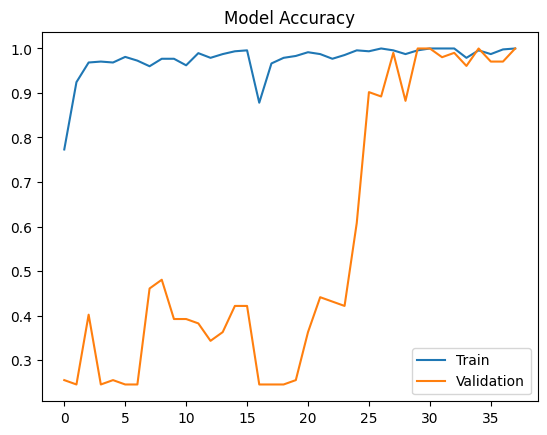

In [11]:
def plot_training(combined_history):
    plt.figure()
    plt.plot(combined_history['accuracy'])
    plt.plot(combined_history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_training(combined_history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step
              precision    recall  f1-score   support

  amr_khaled       0.93      1.00      0.96        26
  heba_allah       1.00      0.84      0.91        25
  yusef_ramy       0.96      0.96      0.96        26
yusef_sameer       0.93      1.00      0.96        25

    accuracy                           0.95       102
   macro avg       0.95      0.95      0.95       102
weighted avg       0.95      0.95      0.95       102



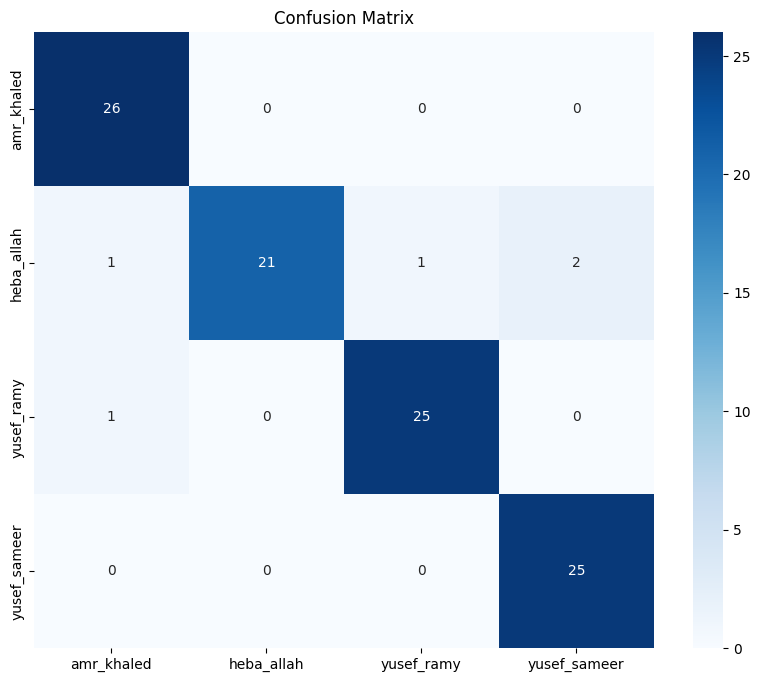

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.show()


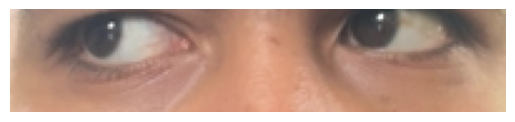

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


(np.str_('amr_khaled'), np.float32(0.9999976))

In [22]:
def predict_image(image_path):
    img_display = plt.imread(image_path)
    img = preprocess_image(image_path, config.IMG_SIZE)
    img = np.expand_dims(img, axis=0)
    plt.imshow(img_display)
    plt.axis("off")
    plt.show()
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)
    return label_encoder.inverse_transform([predicted_class])[0], confidence
predict_image(r"C:\Users\yusuf\jupyter\E_R\DataSet_Y_Y_A_H\amr_khaled\eye_1768134385_696396f1c4cca.png")

In [14]:
model.save("eye_recognition_model.h5")
joblib.dump(label_encoder, "label_encoder.pkl")


['label_encoder.pkl']